In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error,accuracy_score
from sklearn.svm import SVR,SVC
from sklearn.neural_network import MLPRegressor,MLPClassifier
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.feature_selection import RFECV

1.a

In [4]:
red_df = pd.read_csv("winequality-red.csv",delimiter=";")
red_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [5]:
white_df = pd.read_csv("winequality-white.csv",delimiter=";")
white_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [6]:
def split_and_normalise(df):
  X,y = df.drop("quality",axis = 1).values,df["quality"].values
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
  X_train, X_val, y_train,y_val = train_test_split(X_train,y_train,test_size=0.1/0.9,random_state=42)
  # scaler = MinMaxScaler() # not used
  # scaler = StandardScaler()
  # X_train_norm = scaler.fit_transform(X_train)
  # X_val_norm = scaler.fit_transform(X_val)
  # X_test_norm = scaler.transform(X_test)
  # return scaler,X_train_norm,y_train,X_val_norm,y_val,X_test_norm,y_test
  return X_train,y_train,X_val,y_val,X_test,y_test


1.c

In [7]:
def random_forest_model(X_train,y_train,X_val,y_val,X_test,y_test):
  n_estimators = [100,110,120]
  mse_loss = np.inf
  best_estimator = None
  for n in n_estimators:
    rf = RandomForestRegressor(n_estimators = n)
    rf.fit(X_train,y_train)
    y_pred = rf.predict(X_val)
    y_pred = np.round(y_pred).astype(int)
    mse = mean_squared_error(y_val,y_pred)
    if mse < mse_loss:
      mse_loss =  mse
      best_estimator = rf
  y_pred = best_estimator.predict(X_test)
  y_pred = np.round(y_pred).astype(int)
  mse = mean_squared_error(y_test,y_pred)
  print(f"mean squared test error : {mse}")
  return best_estimator

In [8]:
def svm_rbf_model(X_train,y_train,X_val,y_val,X_test,y_test):
  gamma = [0.4,1,1.3,1.4,1.5,2,3]
  mse_loss = np.inf
  best_estimator = None
  for g in gamma:
    svr = SVR(kernel = 'rbf',gamma=g)
    svr.fit(X_train,y_train)
    y_pred = svr.predict(X_val)
    y_pred = np.round(y_pred).astype(int)
    mse = mean_squared_error(y_val,y_pred)
    if mse < mse_loss:
      mse_loss =  mse
      best_estimator = svr
  y_pred = best_estimator.predict(X_test)
  y_pred = np.round(y_pred).astype(int)
  mse = mean_squared_error(y_test,y_pred)
  print(f"mean squared test error : {mse}")
  return best_estimator

In [9]:
X_train,y_train,X_val,y_val,X_test,y_test = split_and_normalise(white_df)

In [10]:
rf_model = random_forest_model(X_train,y_train,X_val,y_val,X_test,y_test)

mean squared test error : 0.40816326530612246


In [11]:
svr_model = svm_rbf_model(X_train,y_train,X_val,y_val,X_test,y_test)

mean squared test error : 0.6244897959183674


In [12]:
RX_train,Ry_train,RX_val,Ry_val,RX_test,Ry_test = split_and_normalise(red_df)

In [13]:
Rrf_model = random_forest_model(RX_train,Ry_train,RX_val,Ry_val,RX_test,Ry_test)

mean squared test error : 0.40625


In [14]:
Rsvr_model = svm_rbf_model(RX_train,Ry_train,RX_val,Ry_val,RX_test,Ry_test)

mean squared test error : 0.5625


e. checking if the model for white will work for red and viceversa

In [15]:
y_pred = Rrf_model.predict(X_test)
y_pred = np.round(y_pred).astype(int)
mean_squared_error(y_test,y_pred)

0.810204081632653

In [16]:
y_pred = Rsvr_model.predict(X_test)
y_pred = np.round(y_pred).astype(int)
mean_squared_error(y_test,y_pred)

0.8326530612244898

In [17]:
Ry_pred = rf_model.predict(RX_test)
Ry_pred = np.round(Ry_pred).astype(int)
mean_squared_error(Ry_test,Ry_pred)

1.3875

In [18]:
Ry_pred = svr_model.predict(RX_test)
Ry_pred = np.round(Ry_pred).astype(int)
mean_squared_error(Ry_test,Ry_pred)

0.76875

### 2

In [19]:
df = pd.read_excel("Data_Cortex_Nuclear.xls",index_col="MouseID")
df

,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,pELK_N,...,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
MouseID,,,,,,,,,,,,,,,,,,,,,
309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,1.750936,...,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m
309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,1.596377,...,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m
309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,1.561316,...,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m
309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,1.595086,...,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m
309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,1.504230,...,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
J3295_11,0.254860,0.463591,0.254860,2.092082,2.600035,0.211736,0.171262,2.483740,0.207317,1.057971,...,0.183324,0.374088,0.318782,0.204660,0.328327,1.364823,Ts65Dn,Saline,S/C,t-SC-s
J3295_12,0.272198,0.474163,0.251638,2.161390,2.801492,0.251274,0.182496,2.512737,0.216339,1.081150,...,0.175674,0.375259,0.325639,0.200415,0.293435,1.364478,Ts65Dn,Saline,S/C,t-SC-s
J3295_13,0.228700,0.395179,0.234118,1.733184,2.220852,0.220665,0.161435,1.989723,0.185164,0.884342,...,0.158296,0.422121,0.321306,0.229193,0.355213,1.430825,Ts65Dn,Saline,S/C,t-SC-s


In [20]:
np.unique(df['Genotype'])

array(['Control', 'Ts65Dn'], dtype=object)

preprocessing

In [21]:
df = df.drop(["Treatment","Behavior","class"],axis=1)
df['Genotype'] = df["Genotype"].map({"Control":0,"Ts65Dn":1})

In [22]:
df

,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,pELK_N,...,BAD_N,BCL2_N,pS6_N,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype
MouseID,,,,,,,,,,,,,,,,,,,,,
309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,1.750936,...,0.122652,NaN,0.106305,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652,0
309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,1.596377,...,0.116682,NaN,0.106592,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610,0
309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,1.561316,...,0.118508,NaN,0.108303,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427,0
309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,1.595086,...,0.132781,NaN,0.103184,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563,0
309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,1.504230,...,0.129954,NaN,0.104784,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
J3295_11,0.254860,0.463591,0.254860,2.092082,2.600035,0.211736,0.171262,2.483740,0.207317,1.057971,...,0.190483,NaN,0.115806,0.183324,0.374088,0.318782,0.204660,0.328327,1.364823,1
J3295_12,0.272198,0.474163,0.251638,2.161390,2.801492,0.251274,0.182496,2.512737,0.216339,1.081150,...,0.190463,NaN,0.113614,0.175674,0.375259,0.325639,0.200415,0.293435,1.364478,1
J3295_13,0.228700,0.395179,0.234118,1.733184,2.220852,0.220665,0.161435,1.989723,0.185164,0.884342,...,0.216682,NaN,0.118948,0.158296,0.422121,0.321306,0.229193,0.355213,1.430825,1


In [23]:
X,y = df.drop(["Genotype"],axis = 1),df["Genotype"]
imputer = IterativeImputer(max_iter = 100,random_state=0)
X_imputed = imputer.fit_transform(X)
X_train,X_test,y_train,y_test = train_test_split(X_imputed,y,test_size=0.1, random_state=42)
X_train,X_val,y_train,y_val = train_test_split(X_imputed,y,test_size=0.1/0.9, random_state=42)

In [24]:
print(len(X_train),len(X_val),len(X_test))

959 121 108


In [25]:
def rfc(X_train,y_train,X_val,y_val,X_test,y_test):
  n_estimators = [100,110,120]
  acc = 0
  best_estimator = None
  for n in n_estimators:
    rf = RandomForestClassifier(n_estimators = n)
    rf.fit(X_train,y_train)
    y_pred = rf.predict(X_val)
    accuracy = accuracy_score(y_val,y_pred)
    print(f"n:{n}, accuracy:{accuracy}")
    if acc < accuracy:
      acc = accuracy
      best_estimator = rf
  y_pred = best_estimator.predict(X_test)
  accu = accuracy_score(y_test,y_pred)
  print(f"test accuracy score : {accu}")
  return best_estimator

In [26]:
def svc(X_train,y_train,X_val,y_val,X_test,y_test):
  gamma = [0.4,1,1.3,1.4,1.5,2,3]
  acc = 0
  best_estimator = None
  for g in gamma:
    svr = SVC(kernel = 'rbf',gamma=g)
    svr.fit(X_train,y_train)
    y_pred = svr.predict(X_val)
    accuracy = accuracy_score(y_val,y_pred)
    print(f"g:{g}, accuracy:{accuracy}")
    if acc < accuracy:
      acc = accuracy
      best_estimator = svr
  y_pred = best_estimator.predict(X_test)
  accu = accuracy_score(y_test,y_pred)
  print(f"test accuracy score : {accu}")
  return best_estimator

In [27]:
rfc_model = rfc(X_train,y_train,X_val,y_val,X_test,y_test)

n:100, accuracy:0.9917355371900827
n:110, accuracy:0.9917355371900827
n:120, accuracy:0.9917355371900827
test accuracy score : 0.9907407407407407


In [28]:
svc_model = svc(X_train,y_train,X_val,y_val,X_test,y_test)

g:0.4, accuracy:0.9834710743801653
g:1, accuracy:0.9917355371900827
g:1.3, accuracy:0.9917355371900827
g:1.4, accuracy:0.9917355371900827
g:1.5, accuracy:0.9917355371900827
g:2, accuracy:0.9917355371900827
g:3, accuracy:0.9917355371900827
test accuracy score : 0.9907407407407407


recursive elimination

In [29]:
estimator = RandomForestClassifier(random_state=42)
selector = RFECV(estimator,step = 1,cv = 5,scoring='accuracy')
selector.fit(X_train,y_train)
print(selector.support_)

[ True  True False False  True False False  True False False  True False
  True False  True False False  True False False  True False False False
 False  True False False False False  True False  True  True  True  True
  True  True  True  True False False  True False False  True  True False
  True  True  True  True False False False False  True False  True False
 False False False False False  True False False False False  True False
  True  True False False  True]


In [30]:
y_pred = selector.predict(X_train)
print(f"accuracy:{accuracy_score(y_train,y_pred)}")

accuracy:1.0


In [31]:
y_pred = selector.predict(X_test)
print(f"accuracy:{accuracy_score(y_test,y_pred)}")

accuracy:0.9907407407407407


It helps in getting an accuracy of 1 in train but not in test set

## question 3

3.a running the given code in the website

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True

In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error,accuracy_score,f1_score
from sklearn.svm import SVR,SVC
from sklearn.neural_network import MLPRegressor,MLPClassifier
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.feature_selection import RFECV

In [39]:
!unzip hymenoptera_data.zip

Archive:  hymenoptera_data.zip
   creating: hymenoptera_data/
   creating: hymenoptera_data/train/
   creating: hymenoptera_data/train/ants/
  inflating: hymenoptera_data/train/ants/0013035.jpg  
  inflating: hymenoptera_data/train/ants/1030023514_aad5c608f9.jpg  
  inflating: hymenoptera_data/train/ants/1095476100_3906d8afde.jpg  
  inflating: hymenoptera_data/train/ants/1099452230_d1949d3250.jpg  
  inflating: hymenoptera_data/train/ants/116570827_e9c126745d.jpg  
  inflating: hymenoptera_data/train/ants/1225872729_6f0856588f.jpg  
  inflating: hymenoptera_data/train/ants/1262877379_64fcada201.jpg  
  inflating: hymenoptera_data/train/ants/1269756697_0bce92cdab.jpg  
  inflating: hymenoptera_data/train/ants/1286984635_5119e80de1.jpg  
  inflating: hymenoptera_data/train/ants/132478121_2a430adea2.jpg  
  inflating: hymenoptera_data/train/ants/1360291657_dc248c5eea.jpg  
  inflating: hymenoptera_data/train/ants/1368913450_e146e2fb6d.jpg  
  inflating: hymenoptera_data/train/ants/147318

In [40]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


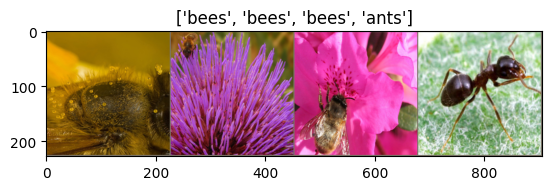

In [41]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [42]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path))
    return model

In [43]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [44]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


In [45]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5561 Acc: 0.7295
val Loss: 0.4105 Acc: 0.8562

Epoch 1/24
----------
train Loss: 0.7483 Acc: 0.7254
val Loss: 0.6903 Acc: 0.7843

Epoch 2/24
----------
train Loss: 0.6837 Acc: 0.7623
val Loss: 0.3660 Acc: 0.8693

Epoch 3/24
----------
train Loss: 0.6623 Acc: 0.7582
val Loss: 0.3383 Acc: 0.8889

Epoch 4/24
----------
train Loss: 0.5232 Acc: 0.7787
val Loss: 0.3230 Acc: 0.8824

Epoch 5/24
----------
train Loss: 0.4280 Acc: 0.8320
val Loss: 0.2901 Acc: 0.8824

Epoch 6/24
----------
train Loss: 0.4702 Acc: 0.8074
val Loss: 0.6386 Acc: 0.7712

Epoch 7/24
----------
train Loss: 0.3432 Acc: 0.8525
val Loss: 0.3739 Acc: 0.8824

Epoch 8/24
----------
train Loss: 0.2612 Acc: 0.8811
val Loss: 0.3057 Acc: 0.8889

Epoch 9/24
----------
train Loss: 0.3415 Acc: 0.8484
val Loss: 0.3017 Acc: 0.9150

Epoch 10/24
----------
train Loss: 0.2510 Acc: 0.8975
val Loss: 0.2772 Acc: 0.9216

Epoch 11/24
----------
train Loss: 0.2463 Acc: 0.8893
val Loss: 0.2978 Acc: 0.9281

Ep

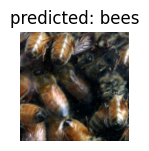

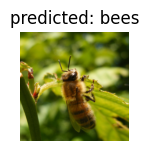

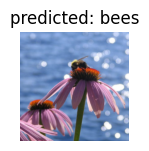

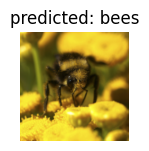

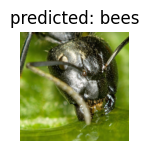

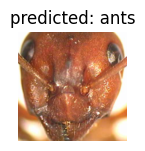

In [46]:
visualize_model(model_ft)

In [47]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [48]:
model_conv = train_model(model_conv, criterion, optimizer_conv,exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.7374 Acc: 0.5861
val Loss: 0.4766 Acc: 0.7712

Epoch 1/24
----------
train Loss: 0.5533 Acc: 0.7500
val Loss: 0.3712 Acc: 0.8431

Epoch 2/24
----------
train Loss: 0.5523 Acc: 0.7705
val Loss: 0.1733 Acc: 0.9477

Epoch 3/24
----------
train Loss: 0.4847 Acc: 0.8115
val Loss: 0.2132 Acc: 0.9346

Epoch 4/24
----------
train Loss: 0.5037 Acc: 0.7951
val Loss: 0.1644 Acc: 0.9542

Epoch 5/24
----------
train Loss: 0.4922 Acc: 0.7828
val Loss: 0.1666 Acc: 0.9477

Epoch 6/24
----------
train Loss: 0.5061 Acc: 0.8156
val Loss: 0.1981 Acc: 0.9477

Epoch 7/24
----------
train Loss: 0.4187 Acc: 0.8197
val Loss: 0.1913 Acc: 0.9346

Epoch 8/24
----------
train Loss: 0.3752 Acc: 0.8197
val Loss: 0.1849 Acc: 0.9412

Epoch 9/24
----------
train Loss: 0.3408 Acc: 0.8402
val Loss: 0.1912 Acc: 0.9346

Epoch 10/24
----------
train Loss: 0.3855 Acc: 0.8033
val Loss: 0.1682 Acc: 0.9412

Epoch 11/24
----------
train Loss: 0.4166 Acc: 0.8156
val Loss: 0.1671 Acc: 0.9542

Ep

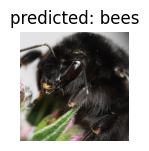

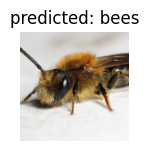

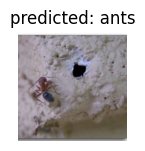

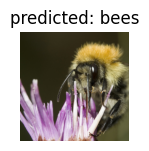

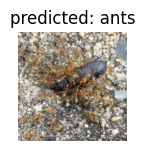

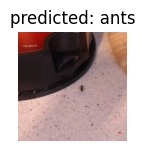

In [49]:
visualize_model(model_conv)

plt.ioff()
plt.show()

In [50]:
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

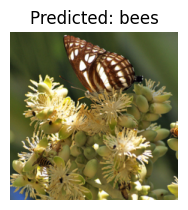

In [51]:
visualize_model_predictions(
    model_conv,
    img_path='hymenoptera_data/val/bees/72100438_73de9f17af.jpg'
)

plt.ioff()
plt.show()

3.b

In [52]:
def feature_extractor(inputs,labels):
  model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
  for param in model_conv.parameters():
    param.requires_grad = False
  model_conv = nn.Sequential(*list(model_conv.children())[:-1])
  # print(model_conv)
  model_conv = model_conv.to(device)
  inputs = inputs.to(device)
  labels = labels.to(device)
  features = model_conv(inputs)
  return features,labels

In [53]:
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=len(image_datasets[x])) for x in ['train', 'val']}
features,labels = None,None
for input,label in dataloaders["train"]:
  features,labels = feature_extractor(input,label)
  features = features.cpu().numpy()
  features = np.squeeze(features,axis=(2,3))
  labels = labels.cpu().numpy()

In [54]:
features_test,labels_test = None,None
for input,label in dataloaders["val"]:
  features_test,labels_test = feature_extractor(input,label)
  features_test = features_test.cpu().numpy()
  features_test = np.squeeze(features_test,axis=(2,3))
  labels_test = labels_test.cpu().numpy()

In [55]:
print(labels.shape)

(244,)


In [56]:
svc = SVC(kernel="rbf")
param_grid = {
    "C":[0.01,0.05,0.5,1],
    "gamma":[0.01,0.1,0.3,0.6]
}
svc_gridsearch = GridSearchCV(estimator=svc,param_grid=param_grid,scoring='accuracy')
svc_gridsearch.fit(features,labels)
best_svc_model = svc_gridsearch.best_estimator_
y_pred = best_svc_model.predict(features_test)
print(f"accuracy:{accuracy_score(labels_test,y_pred)}")
print(f"F1-score :{f1_score(labels_test,y_pred)}")

accuracy:0.9281045751633987
F1-score :0.930817610062893


In [57]:
rf = RandomForestClassifier()
param_grid = {
    "n_estimators":[100,150,170,200],
    "max_depth":[10,13,14,17]
}
rf_gridsearch = GridSearchCV(estimator=rf,param_grid=param_grid,scoring='accuracy')
rf_gridsearch.fit(features,labels)
best_rf_model = rf_gridsearch.best_estimator_
y_pred = best_rf_model.predict(features_test)
print(f"accuracy:{accuracy_score(labels_test,y_pred)}")
print(f"F1-score :{f1_score(labels_test,y_pred)}")

accuracy:0.9281045751633987
F1-score :0.930817610062893
